## Хомутинников А.А. ИУ5-62Б

### РК1 Вариант 21

### Задача №3.
Для заданного набора данных произведите масштабирование данных (для одного признака) и преобразование категориальных признаков в количественные двумя способами (label encoding, one hot encoding) для одного признака. Какие методы Вы использовали для решения задачи и почему?

Для студентов групп ИУ5-62Б, ИУ5Ц-82Б - для произвольной колонки данных построить гистограмму.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

In [3]:
data = pd.read_csv('Admission_predict.csv', sep=",")

In [4]:
data.shape

(400, 9)

In [5]:
data.dtypes

Serial No.             int64
GRE Score              int64
TOEFL Score            int64
University Rating      int64
SOP                  float64
LOR                  float64
CGPA                 float64
Research               int64
Chance of Admit      float64
dtype: object

In [7]:
data.isnull().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [6]:
data.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


### Масштабирование колонки GRE Score

In [31]:
data['University Rating'].unique()

array([4, 3, 2, 5, 1])

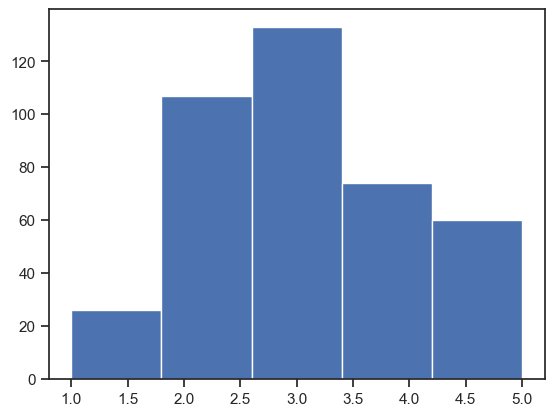

In [25]:
plt.hist(data[['University Rating']], 5)
plt.show()

In [13]:
from sklearn.preprocessing import MinMaxScaler

In [28]:
sc = MinMaxScaler()
sc_data = sc.fit_transform(data[['University Rating']])

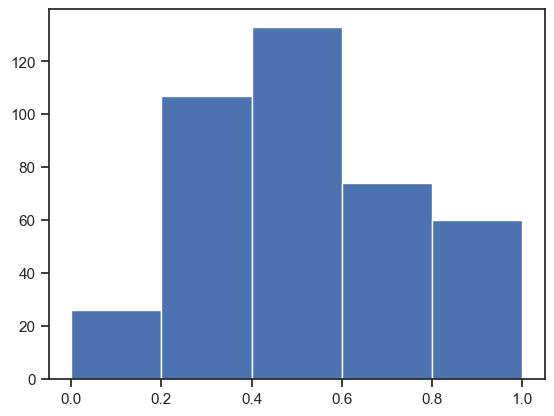

In [29]:
plt.hist(sc_data, 5)
plt.show()

### Кодирование признака University rating

Сначала сделаем его категориальным:

In [33]:
rating_map = {
    1: "a",
    2: "b",
    3: "c",
    4: "d",
    5: "e"
}

data["University Rating cat"] = data["University Rating"].map(rating_map)

In [34]:
data["University Rating cat"].unique()

array(['d', 'c', 'b', 'e', 'a'], dtype=object)

### Label Encoder

In [35]:
from sklearn.preprocessing import LabelEncoder

In [45]:
le = LabelEncoder()
cat_enc_le = le.fit_transform(data['University Rating cat'])

In [39]:
cat_enc_le

array([3, 3, 2, 2, 1, 4, 2, 1, 0, 2, 2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 3,
       4, 4, 4, 4, 4, 1, 0, 1, 1, 2, 3, 4, 4, 4, 1, 0, 0, 1, 2, 1, 1, 3,
       4, 4, 4, 4, 2, 3, 2, 1, 3, 3, 2, 2, 2, 1, 0, 1, 1, 2, 1, 1, 2, 3,
       2, 1, 2, 3, 4, 4, 4, 3, 2, 1, 2, 1, 1, 0, 2, 3, 4, 4, 4, 3, 2, 1,
       2, 3, 1, 2, 1, 1, 2, 3, 1, 2, 3, 2, 2, 1, 1, 1, 2, 2, 3, 3, 4, 4,
       4, 3, 2, 1, 2, 3, 2, 3, 1, 4, 4, 4, 3, 2, 3, 2, 2, 2, 2, 4, 4, 4,
       4, 4, 4, 3, 2, 1, 1, 0, 1, 1, 4, 3, 1, 1, 2, 2, 3, 1, 3, 4, 4, 2,
       2, 2, 2, 1, 1, 0, 0, 0, 2, 2, 3, 4, 2, 2, 1, 1, 1, 4, 3, 3, 3, 3,
       3, 2, 2, 2, 2, 1, 1, 2, 1, 3, 2, 4, 4, 4, 4, 4, 4, 4, 2, 1, 1, 1,
       2, 2, 2, 1, 4, 4, 2, 1, 1, 2, 1, 2, 3, 3, 3, 4, 3, 4, 3, 3, 3, 2,
       2, 2, 3, 1, 1, 1, 1, 1, 2, 3, 2, 2, 1, 1, 4, 4, 3, 4, 2, 0, 0, 1,
       2, 2, 1, 3, 2, 1, 2, 2, 2, 1, 1, 3, 3, 3, 2, 2, 3, 3, 4, 2, 1, 2,
       1, 2, 1, 2, 3, 3, 1, 1, 0, 0, 0, 2, 4, 1, 1, 1, 2, 2, 2, 2, 3, 4,
       4, 4, 3, 2, 1, 1, 1, 0, 1, 1, 2, 2, 2, 2, 1,

### One hot encoding

In [41]:
from sklearn.preprocessing import OneHotEncoder

In [43]:
ohe = OneHotEncoder()
cat_enc_ohe = ohe.fit_transform(data[['University Rating cat']])

In [46]:
cat_enc_ohe.shape

(400, 5)

In [49]:
cat_enc_ohe.todense()[0:10]

matrix([[0., 0., 0., 1., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0.],
        [0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0.]])